In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [3]:
df = pd.read_csv("college_student_placement_dataset.csv")

df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [5]:
df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [6]:
print(df["Internship_Experience"].unique())

['No' 'Yes']


In [7]:
print(df["Placement"].unique())

['No' 'Yes']


In [8]:
df["Internship_Experience"] = df["Internship_Experience"].map({
    "No": 0,
    "Yes": 1
})

df["Placement"] = df["Placement"].map({
    "No": 0,
    "Yes": 1
})

In [9]:
print(df["Internship_Experience"].unique())
print(df["Placement"].unique())

[0 1]
[0 1]


In [10]:
X = df[
    [
        "Prev_Sem_Result",
        "CGPA",
        "Internship_Experience",
        "Extra_Curricular_Score",
        "Communication_Skills",
        "Projects_Completed"
    ]
]

y = df["Placement"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)

Accuracy: 91.05


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1674
           1       0.89      0.51      0.65       326

    accuracy                           0.91      2000
   macro avg       0.90      0.75      0.80      2000
weighted avg       0.91      0.91      0.90      2000



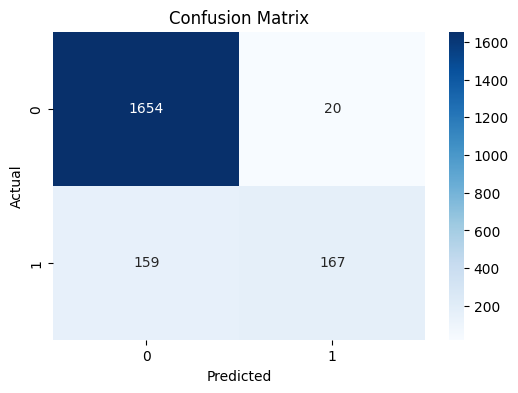

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

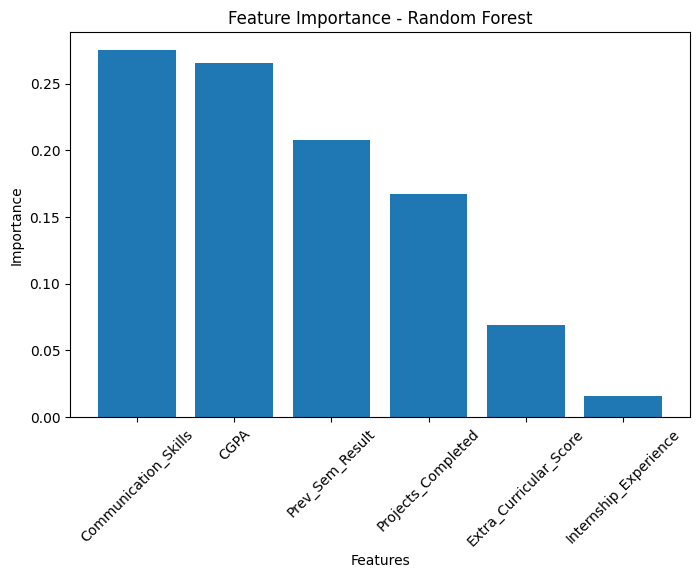

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")

plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}


results = []


for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy * 100
    })


comparison = pd.DataFrame(results)

print(comparison)

                 Model  Accuracy
0  Logistic Regression     87.45
1        Decision Tree     86.05
2        Random Forest     91.05


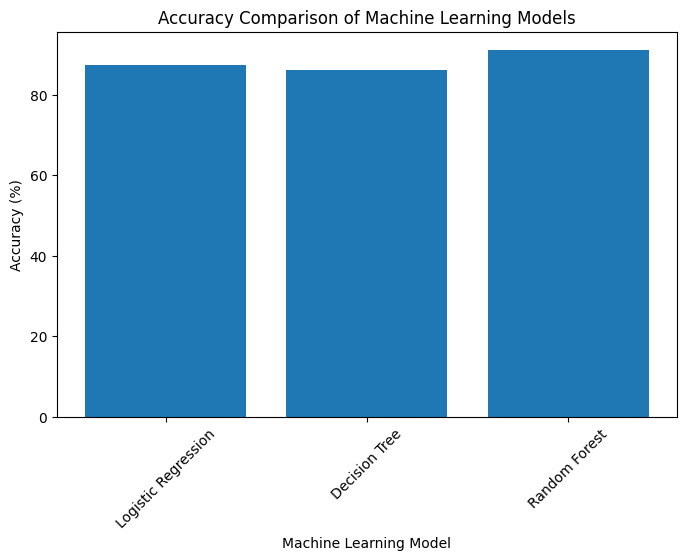

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Machine Learning Models")

plt.xticks(rotation=45)

plt.show()

In [21]:
print(X.columns)

Index(['Prev_Sem_Result', 'CGPA', 'Internship_Experience',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed'],
      dtype='object')


In [22]:
X.columns

Index(['Prev_Sem_Result', 'CGPA', 'Internship_Experience',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed'],
      dtype='object')

In [23]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(random_state=42)

final_model.fit(X_train, y_train)

print("Final model trained")

Final model trained


In [24]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = final_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred)*100)

print(classification_report(y_test, y_pred))

Accuracy: 91.05
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1674
           1       0.89      0.51      0.65       326

    accuracy                           0.91      2000
   macro avg       0.90      0.75      0.80      2000
weighted avg       0.91      0.91      0.90      2000



In [25]:
import joblib

joblib.dump(final_model, "placement_model.pkl")

print("Model saved successfully")

Model saved successfully


In [26]:
df["Communication_Skills"].describe()

count    10000.000000
mean         5.561800
std          2.900866
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: Communication_Skills, dtype: float64